In [1]:
import sys, os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from typing import List, Dict, Any, Optional, Tuple

import glob
import re
from tqdm.auto import tqdm
from pathlib import Path

import matplotlib.pyplot as plt

# Add project root to path
PROJECT_ROOT = "/mnt/c/Users/obbee/research/notebooks/ML"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
    os.environ["PYTHONPATH"] = PROJECT_ROOT + os.pathsep + os.environ.get("PYTHONPATH", "")

from torch.nn.utils import clip_grad_norm_
from graph_data.utils import (
    GraphGroupDataset,
    PION_MASK, MUON_MASK, POSITRON_MASK, ELECTRON_MASK, OTHER_MASK
)
from graph_data.models import GroupSplitter
from torch_geometric.data import Batch

/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
_CHUNK_INDEX_RE = re.compile(r"_(\d+)\.npy$")

NUM_NODE_CLASSES = 3  # channels: [pion, muon, mip]
NODE_LABEL_TO_NAME = {0: "pion", 1: "muon", 2: "mip"}

PI_IDX, MU_IDX, MIP_IDX = 0, 1, 2

PAIR_TYPES = ["pi-mu", "mu-mip", "pi-mip"]

PAIR_SPECIES = {
    "pi-mu":  (PI_IDX, MU_IDX),
    "mu-mip": (MU_IDX, MIP_IDX),
    "pi-mip": (PI_IDX, MIP_IDX),
}

PAIR_CLASS_NAMES = {
    "pi-mu":  ["pion", "muon", "pion+muon"],
    "mu-mip": ["muon", "mip", "muon+mip"],
    "pi-mip": ["pion", "mip", "pion+mip"],
}

GROUP_TYPE_INDEX = {
    "pi-mu":  0,
    "mu-mip": 1,
    "pi-mip": 2,
}

In [ ]:
def _extract_file_index(path: Path) -> Optional[int]:
    """Return the numeric suffix from a chunk filename, if present."""
    match = _CHUNK_INDEX_RE.search(path.name)
    return int(match.group(1)) if match else None

def _multilabel_from_mask(mask: int) -> Optional[List[int]]:
    """Return [is_pion, is_muon, is_mip] as ints 0/1, or None to drop hit."""
    has_pion = bool(mask & PION_MASK)
    has_muon = bool(mask & MUON_MASK)
    has_pos  = bool(mask & POSITRON_MASK)
    has_ele  = bool(mask & ELECTRON_MASK)

    has_mip = has_pos or has_ele

    # Drop pure OTHER hits: no pion/muon/e± content at all
    if not (has_pion or has_muon or has_mip):
        return None

    return [
        int(has_pion),
        int(has_muon),
        int(has_mip),
    ]

def is_multispecies_group(node_labels: np.ndarray) -> bool:
    """
    node_labels: [N, 3] array of 0/1 for [pion, muon, mip].
    Returns True if the group contains >= 2 particle species.
    """
    species_present = node_labels.sum(axis=0) > 0  # boolean array of shape [3]
    num_species = species_present.sum()
    return num_species >= 2

def load_splitter_groups_vectorized(
    data_dir: str,
    *,
    limit_groups: Optional[int] = None,
    min_hits: int = 2,
    verbose: bool = True,
) -> List[Dict[str, Any]]:
    
    hits_pattern = os.path.join(data_dir, "hits_batch_*.npy")
    paths = sorted(glob.glob(hits_pattern), key=lambda p: _extract_file_index(Path(p)) or -1)
    
    if not paths:
        print(f"No files found in {data_dir}")
        return []

    print(f"Found {len(paths)} hit files. Starting processing...")

    records: List[Dict[str, Any]] = []
    # per-channel totals: [pion_hits, muon_hits, mip_hits]
    label_totals = np.zeros(3, dtype=int)

    for path in tqdm(paths, desc="Processing Files", unit="file"):
        if limit_groups is not None and len(records) >= limit_groups:
            break
            
        try:
            # Note: This load is still the bottleneck due to pickle format
            chunk = np.load(path, allow_pickle=True)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            continue

        chunk_index = _extract_file_index(Path(path)) or 0

        # Enumerate events in the chunk -- TO FIX: This loops over the chunk assuming events, but we actually have time groups so this loop needs to be removed.

        for group_offset, raw_group in enumerate(chunk):
            if limit_groups is not None and len(records) >= limit_groups:
                break
            if raw_group is None:
                continue    

            # 1. Convert to array (Initial overhead, but necessary)
            group = np.asarray(raw_group)
            
            # Check basic shape requirements
            if group.ndim != 2 or group.shape[0] < min_hits or group.shape[1] < 5:
                continue

            # --- VECTORIZED LOGIC STARTS HERE ---
            
            # 2. Extract Masks
            mask_values = group[:, 4].astype(int)

            # 3. Create Booleans (Replaces _multilabel_from_mask)
            is_pion = (mask_values & PION_MASK) > 0
            is_muon = (mask_values & MUON_MASK) > 0
            is_pos  = (mask_values & POSITRON_MASK) > 0
            is_ele  = (mask_values & ELECTRON_MASK) > 0
            
            # Definition: MIP is Positron OR Electron
            is_mip  = is_pos | is_ele

            # 4. Identify Valid Hits (Not pure "Other")
            # Equivalent to: if not (has_pion or has_muon or has_mip): return None
            valid_mask = is_pion | is_muon | is_mip

            # If no hits in the entire group are valid, skip
            if not valid_mask.any():
                continue

            # 5. Filter Data and Labels
            # We apply the boolean mask to filter rows
            filtered_group = group[valid_mask]
            
            # Stack the bools to create the [N, 3] label array
            # resulting shape: (num_valid_hits, 3)
            hit_labels = np.stack([
                is_pion[valid_mask], 
                is_muon[valid_mask], 
                is_mip[valid_mask]
            ], axis=1).astype(int)

            # 6. Check Hit Count (Replaces: if len(node_labels) < 1)
            if len(hit_labels) < 2:
                continue

            # 7. Check Multispecies (Replaces: is_multispecies_group)
            # Logic: Does the group contain >= 2 different particle types?
            # Sum columns to get total hits per species
            species_counts = hit_labels.sum(axis=0) 
            # Count how many species have > 0 hits
            num_species_present = (species_counts > 0).sum()
            
            if num_species_present < 2:
                continue

            # --- END VECTORIZED LOGIC ---

            # 8. Update Stats
            label_totals += species_counts

            # 9. Extract Features
            coord = filtered_group[:, 0].astype(np.float32)
            z_pos = filtered_group[:, 1].astype(np.float32)
            view_flag = filtered_group[:, 2].astype(np.float32)
            energy = filtered_group[:, 3].astype(np.float32)

            # 10. Extract Event ID (Preserving your exact fallback logic)
            record_event_id: Optional[int] = None
            if filtered_group.shape[1] > 5:
                try:
                    record_event_id = int(filtered_group[0, 5])
                except (ValueError, TypeError):
                    record_event_id = None
            
            if record_event_id is None:
                record_event_id = chunk_index * 100000 + group_offset
            
            class_energies = hit_labels.T @ energy

            records.append({
                'coord': coord,
                'z': z_pos,
                'view': view_flag,
                'energy': energy,
                'hit_labels': hit_labels, # shape [num_hits, 3]
                'class_energies': class_energies,
                'event_id': record_event_id,
                'group_id': len(records),
            })

    if verbose:
        total_hits = label_totals.sum()
        pion_hits, muon_hits, mip_hits = label_totals.tolist()
        print(
            f"\nLoaded {len(records)} splitter groups from {len(paths)} files; "
            f"pion_hits={pion_hits}, muon_hits={muon_hits}, mip_hits={mip_hits}, total_hits={total_hits}"
        )

    return records

def _split_groups(groups: List[Dict[str, Any]], train_fraction: float, seed: int) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    if len(groups) <= 1:
        return list(groups), []
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(groups))
    train_size = max(1, int(len(groups) * train_fraction))
    if train_size >= len(groups):
        train_size = len(groups) - 1
    train_idx = indices[:train_size]
    val_idx = indices[train_size:]
    return [groups[i] for i in train_idx], [groups[i] for i in val_idx]

In [4]:
def _init_confusion() -> np.ndarray:
    n_pairs = len(PAIR_TYPES)  # 3: "pi-mu", "mu-mip", "pi-mip"
    n_cls = 3                  # A only, B only, A+B
    return np.zeros((n_pairs, n_cls, n_cls), dtype=np.int64)

def _pair_class(bits: np.ndarray, idx_a: int, idx_b: int) -> Optional[int]:
    """
    bits: [3] array of 0/1 for [pi, mu, mip].
    idx_a, idx_b: which entries correspond to species A and B.
    Returns:
      0 -> A only
      1 -> B only
      2 -> A+B
      None -> ignore this hit for confusion (neither A nor B).
    """
    a = int(bits[idx_a])
    b = int(bits[idx_b])

    if a == 1 and b == 0:
        return 0
    elif a == 0 and b == 1:
        return 1
    elif a == 1 and b == 1:
        return 2
    else:
        return None  # (0,0) or irrelevant for this pair

def update_confusion_for_group(confusion, truth_labels, pred_labels):
    # Determine group type
    has_pi  = truth_labels[:, 0].any()
    has_mu  = truth_labels[:, 1].any()
    has_mip = truth_labels[:, 2].any()

    if has_pi and has_mu and not has_mip:
        gtype = "pi-mu"
    elif has_mu and has_mip and not has_pi:
        gtype = "mu-mip"
    elif has_pi and has_mip and not has_mu:
        gtype = "pi-mip"
    else:
        return  # skip for confusion

    gidx = GROUP_TYPE_INDEX[gtype]
    idx_a, idx_b = PAIR_SPECIES[gtype]

    for t_bits, p_bits in zip(truth_labels, pred_labels):
        t_cls = _pair_class(t_bits, idx_a, idx_b)
        p_cls = _pair_class(p_bits, idx_a, idx_b)
        if t_cls is None or p_cls is None:
            continue
        confusion[gidx, t_cls, p_cls] += 1

def _plot_confusion(title: str, confusion: np.ndarray, epoch: int) -> None:
    """
    confusion: [3 pair types, 3 truth classes, 3 pred classes]
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), squeeze=False)
    fig.suptitle(f"{title} hit-level confusion — epoch {epoch}")

    for gi, pair_name in enumerate(PAIR_TYPES):
        mat = confusion[gi]  # [3,3]
        row_sums = mat.sum(axis=1, keepdims=True)
        with np.errstate(divide='ignore', invalid='ignore'):
            norm = np.divide(
                mat,
                row_sums,
                out=np.zeros_like(mat, dtype=float),
                where=row_sums != 0,
            )

        ax = axes[0, gi]
        im = ax.imshow(norm, cmap='Blues', vmin=0.0, vmax=1.0)
        cls_names = PAIR_CLASS_NAMES[pair_name]
        ax.set_title(pair_name)
        ax.set_xticks(range(3))
        ax.set_yticks(range(3))
        ax.set_xticklabels(cls_names, rotation=30, ha='right')
        ax.set_yticklabels(cls_names)

        for i in range(3):
            for j in range(3):
                val = norm[i, j]
                count = mat[i, j]
                color = 'white' if val > 0.6 else 'black'
                ax.text(j, i, f"{val:.3f}\n({count:d})", ha='center', va='center', color=color, fontsize=8)

    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
    plt.show()

def plot_energy_residuals(residuals: dict, epoch: int):
    """
    Plots the distribution of (Predicted - True) energy for each particle class.
    residuals: Dictionary {class_idx: list_of_errors}
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    class_names = ["Pion", "Muon", "MIP"]
    
    for i in range(3):
        ax = axes[i]
        data = residuals[i]
        
        if len(data) > 0:
            # Calculate stats
            mean_err = np.mean(data)
            std_err = np.std(data)
            
            # Plot histogram
            ax.hist(data, bins=50, alpha=0.7, color='royalblue', label='Residuals')
            
            # Add vertical line for mean
            ax.axvline(mean_err, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_err:.3f}')
            
            # Styling
            ax.set_title(f'{class_names[i]} Energy Error (Epoch {epoch})')
            ax.set_xlabel('Pred - True Energy [MeV]')
            ax.set_ylabel('Count')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            # Add text box with stats
            stats_text = f'Mean: {mean_err:.3f}\nStd:  {std_err:.3f}'
            ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.5, 0.5, "No Data", ha='center', va='center')
            
    plt.tight_layout()
    plt.show()

def train_splitter(
    groups: List[Dict[str, Any]],
    *,
    model: Optional[GroupSplitter] = None,
    batch_size: int = 64,
    epochs: int = 20,
    lr: float = 1e-3,
    energy_lambda: float = 1.0,
    device: Optional[str] = None,
    grad_clip: Optional[float] = None,
    threshold: float = 0.5,
):
    if not groups:
        raise ValueError('No groups provided for training.')

    device_str = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    device_obj = torch.device(device_str)
    print(f"Using device: {device_obj}")

    train_groups, val_groups = _split_groups(groups, train_fraction=0.9, seed=42)
    
    # GraphGroupDataset will now put hit_labels into data.y
    train_dataset = GraphGroupDataset(train_groups, num_classes=NUM_NODE_CLASSES)
    val_dataset = GraphGroupDataset(val_groups, num_classes=NUM_NODE_CLASSES) if val_groups else None
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) if val_dataset else None

    model = model.to(device_obj) if model else GroupSplitter(in_channels=4, num_classes=NUM_NODE_CLASSES).to(device_obj)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    
    # BCEWithLogitsLoss for multi-label
    pos_weight = torch.tensor([1.0, 2.0, 1.0], device=device_obj)
    criterion_node = nn.BCEWithLogitsLoss(pos_weight=pos_weight) #Penalize failures to identify muon --> low muon hit multiplicity biases model to not predict muon hits otherwise
    #criterion_node = nn.BCEWithLogitsLoss()
    criterion_energy = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_node_loss = 0.0
        total_energy_loss = 0.0
        total_correct = 0
        total_examples = 0
        train_conf = _init_confusion()
        energy_weights = torch.tensor([0.3, 1.0, 1.0], device=device_obj)
        
        for batch in train_loader:
            batch = batch.to(device_obj)
            optimizer.zero_grad()
            
            node_logits, energy_preds = model(batch)
            
            # batch.y contains hit_labels [total_nodes, 3]
            if not hasattr(batch, 'y'):
                 continue
            
            targets = batch.y
            loss_node = criterion_node(node_logits, targets)
            
            # Energy regression loss (if available)
            if hasattr(batch, 'y_energy'):
                
                # shape: [batch_size, 3]
                squared_errors = (energy_preds - batch.y_energy) ** 2
                
                # Apply weights
                weighted_errors = squared_errors * energy_weights
                
                # Mean reduction
                loss_energy = weighted_errors.mean()
            else:
                loss_energy = torch.tensor(0.0, device=device_obj)
                print("No energy targets found in batch")
            
            loss = loss_node + energy_lambda * loss_energy
            
            loss.backward()
            if grad_clip is not None:
                clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            
            batch_size_curr = batch.num_graphs
            total_loss += loss.item() * batch_size_curr
            total_node_loss += loss_node.item() * batch_size_curr
            total_energy_loss += loss_energy.item() * batch_size_curr
            
            with torch.no_grad():
                probs = torch.sigmoid(node_logits)
                preds = (probs > threshold).float()
                
                # Exact match accuracy
                correct = (preds == targets).all(dim=1).sum().item()
                total_correct += correct
                total_examples += targets.size(0)
                
                # Confusion
                offset = 0
                for graph in batch.to_data_list():
                    num_hits = graph.num_nodes
                    t_slice = targets[offset:offset + num_hits].cpu().numpy()
                    p_slice = preds[offset:offset + num_hits].cpu().numpy()
                    update_confusion_for_group(train_conf, t_slice, p_slice)
                    offset += num_hits

        avg_loss = total_loss / len(train_groups)
        avg_node_loss = total_node_loss / len(train_groups)
        avg_energy_loss = total_energy_loss / len(train_groups)
        train_acc = total_correct / max(total_examples, 1)
        
        print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} (Node: {avg_node_loss:.4f}, Energy: {avg_energy_loss:.4f}) | Node Acc: {train_acc:.4f}")
        _plot_confusion('Train', train_conf, epoch)

        val_residuals = {0: [], 1: [], 2: []} 
        if val_loader:
            model.train() #Leave dropout on so we can do MC dropout
            val_loss = 0.0
            val_correct = 0
            val_examples = 0
            val_conf = _init_confusion()

            num_MC_dropout_samples = 5
            
            with torch.no_grad():
                for batch in val_loader:

                    # We now set up MC dropout -- on the CPU we make copies of all graphs and then move them to GPU where they can be evaluated in parallel and then averaged

                    data_list = batch.to_data_list()
                    replicated_list = data_list * num_MC_dropout_samples
                    large_batch = Batch.from_data_list(replicated_list)
                    
                    large_batch = large_batch.to(device_obj) # Move to GPU
                    node_logits, energy_preds = model(large_batch) # [num_MC_dropout_samples * batch_size, 3]

                    batch_size_curr = batch.num_graphs
                    energy_reshaped = energy_preds.view(num_MC_dropout_samples, batch_size_curr, 3).mean(dim=0) # [batch_size, 3] the energies are now averaged over the MC samples and back in the original batch shape
                    
                    if hasattr(batch, 'y_energy'):

                        squared_errors = (energy_reshaped - batch.y_energy.to(device_obj)) ** 2
                        # Apply weights
                        weighted_errors = squared_errors * energy_weights
                        
                        # Mean reduction
                        l_energy = weighted_errors.mean()

                        #l_energy = criterion_energy(energy_preds, batch.y_energy)
                        preds = energy_reshaped.cpu().numpy()
                        truth = batch.y_energy.cpu().numpy()
                        diff = preds - truth
                        
                        for i in range(3):
                            # Only collect errors where the particle actually exists (truth > 0)
                            mask = truth[:, i] > 0
                            if mask.any():
                                val_residuals[i].extend(diff[mask, i].tolist())
                    else:
                        l_energy = torch.tensor(0.0, device=device_obj)


                    # Reshape node logits to [batch_size, 3]
                    total_num_nodes = batch.num_nodes
                    node_logits_reshaped = node_logits.view(num_MC_dropout_samples, total_num_nodes, 3)

                    probs = torch.sigmoid(node_logits_reshaped).mean(dim=0)
                    preds = (probs > threshold).float()

                    targets = batch.y.to(device_obj)
                    l_node = criterion_node(node_logits_reshaped.mean(dim=0), targets)
                        
                    loss = l_node + energy_lambda * l_energy
                    val_loss += loss.item() * batch.num_graphs
                    
                    correct = (preds == targets).all(dim=1).sum().item()
                    val_correct += correct
                    val_examples += targets.size(0)
                    
                    offset = 0
                    for graph in batch.to_data_list():
                        num_hits = graph.num_nodes
                        t_slice = targets[offset:offset + num_hits].cpu().numpy()
                        p_slice = preds[offset:offset + num_hits].cpu().numpy()
                        update_confusion_for_group(val_conf, t_slice, p_slice)
                        offset += num_hits
            
            avg_val_loss = val_loss / len(val_groups)
            val_acc = val_correct / max(val_examples, 1)
            print(f"         | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
            _plot_confusion('Val', val_conf, epoch)
            plot_energy_residuals(val_residuals, epoch)
    return model

In [5]:
data_dir = "npy_data"
print("Loading data...")
groups = load_splitter_groups_vectorized(data_dir, limit_groups=1000)
print(f"Loaded {len(groups)} groups.")

Loading data...
Found 289 hit files. Starting processing...


Processing Files:   1%|▏         | 4/289 [00:45<53:46, 11.32s/file]


Loaded 1000 splitter groups from 289 files; pion_hits=28166, muon_hits=5100, mip_hits=367, total_hits=33633
Loaded 1000 groups.


In [6]:
model = GroupSplitter(in_channels=4, num_classes=NUM_NODE_CLASSES, hidden=100, layers=2, dropout=0.05)

Using device: cuda
Epoch 01 | Train Loss: 12.2270 (Node: 0.6331, Energy: 11.5939) | Node Acc: 0.1751


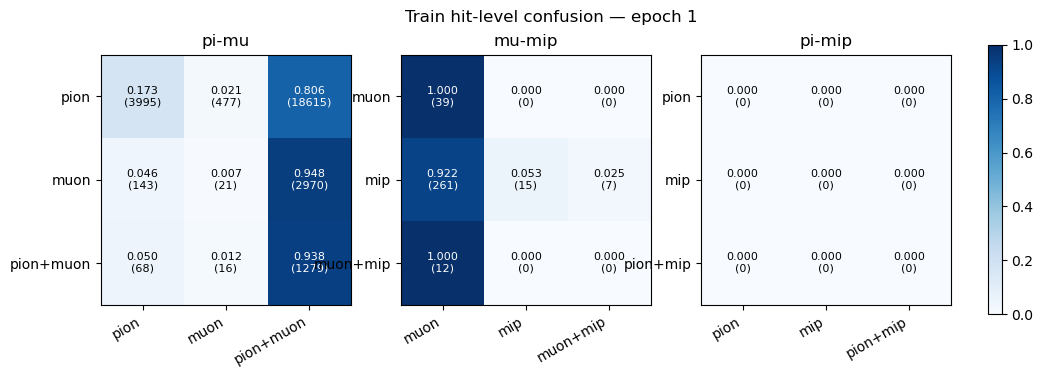

         | Val Loss: 5.7425 | Val Acc: 0.1569


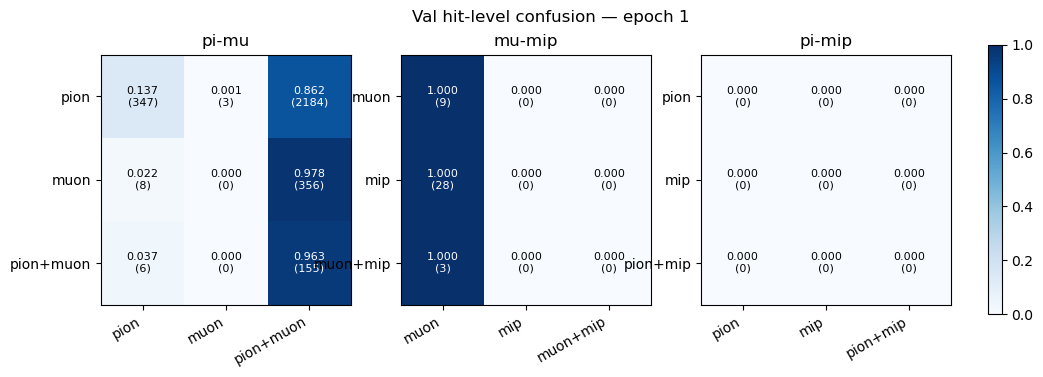

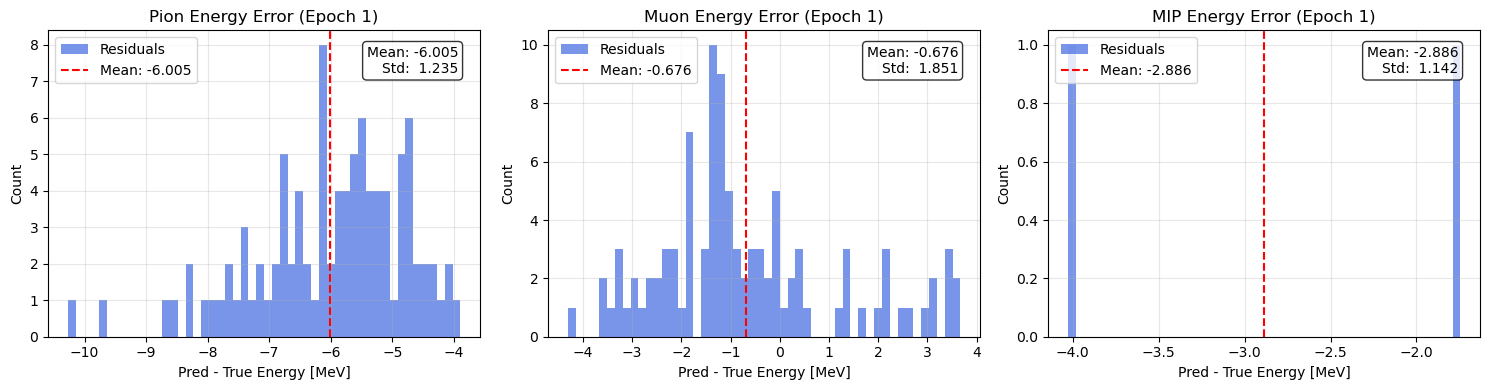

Epoch 02 | Train Loss: 3.4380 (Node: 0.5178, Energy: 2.9201) | Node Acc: 0.3504


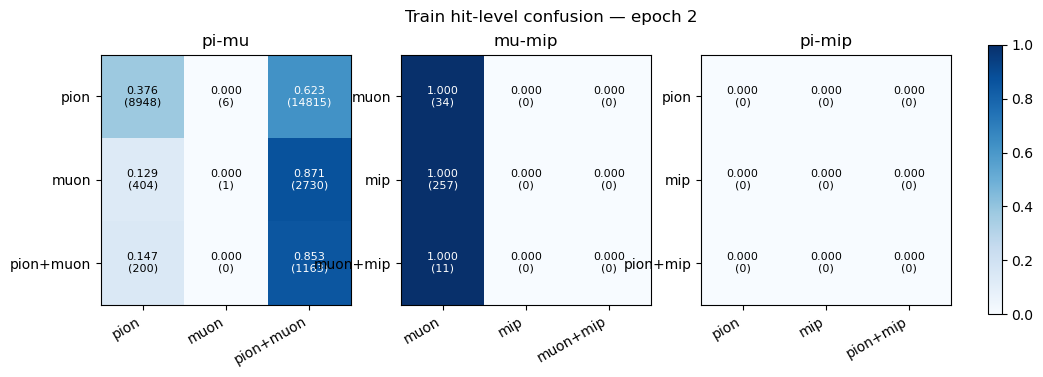

         | Val Loss: 2.2076 | Val Acc: 0.5769


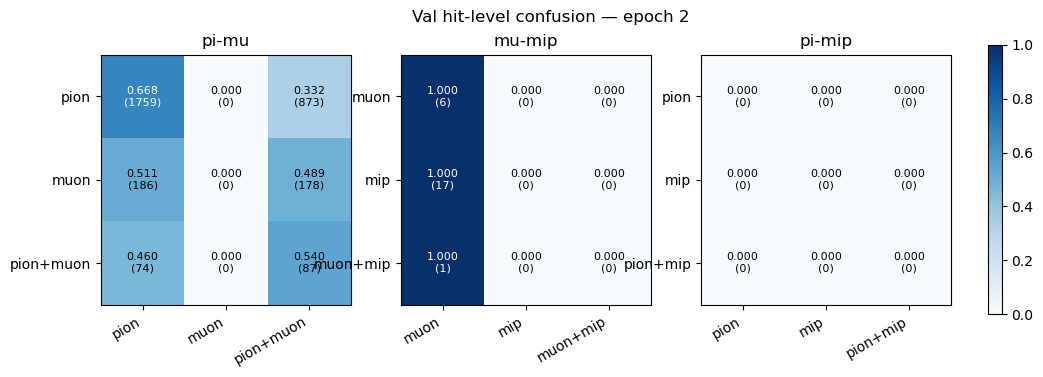

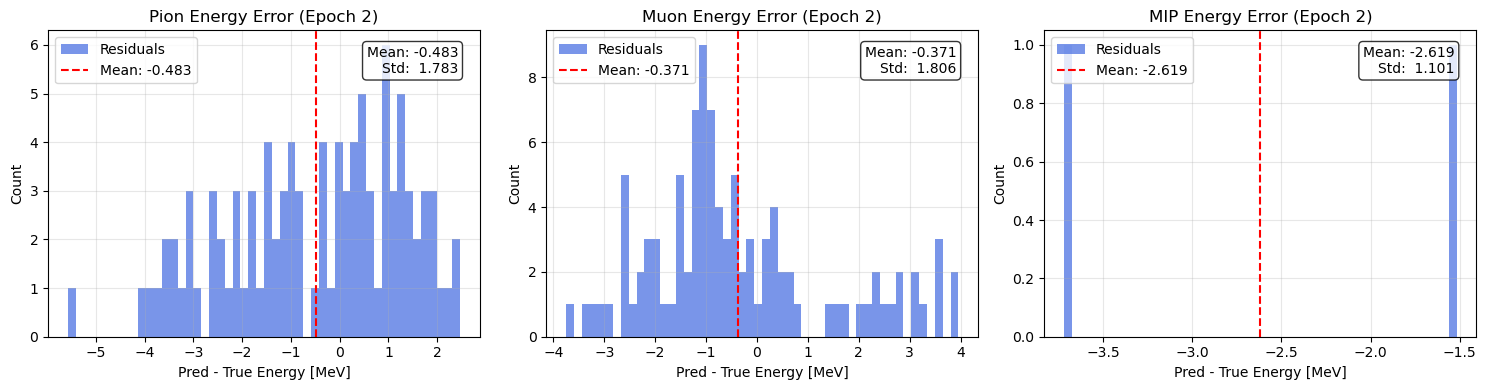

Epoch 03 | Train Loss: 1.9300 (Node: 0.3746, Energy: 1.5554) | Node Acc: 0.7215


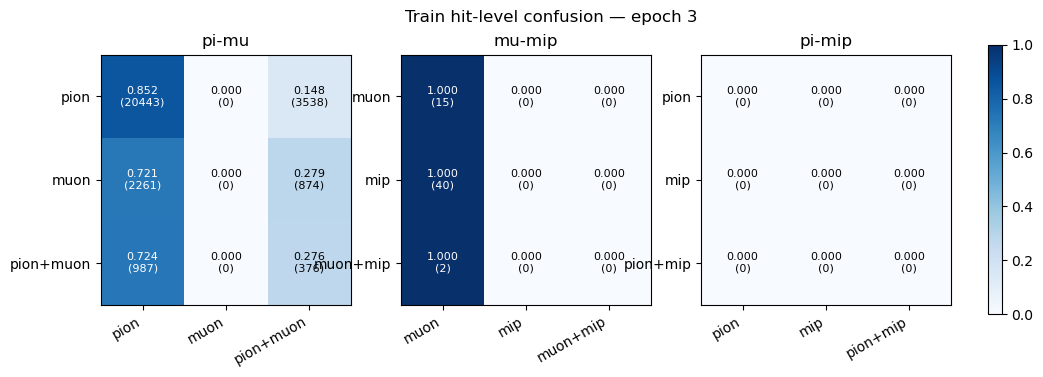

         | Val Loss: 1.8482 | Val Acc: 0.7959


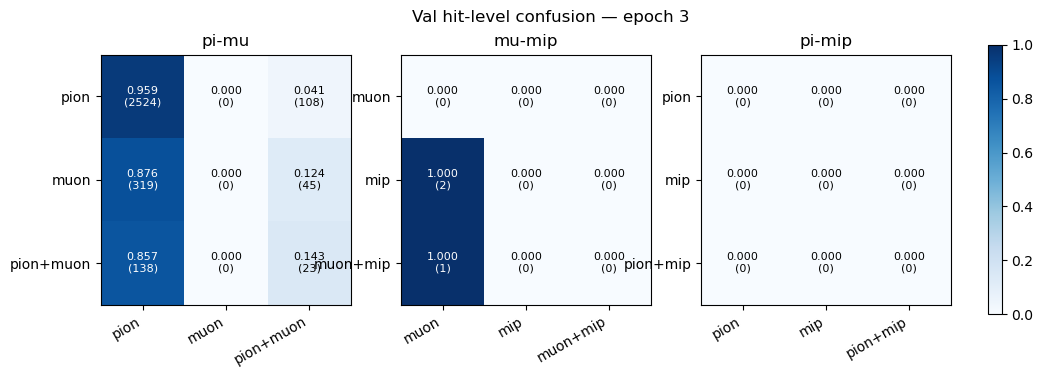

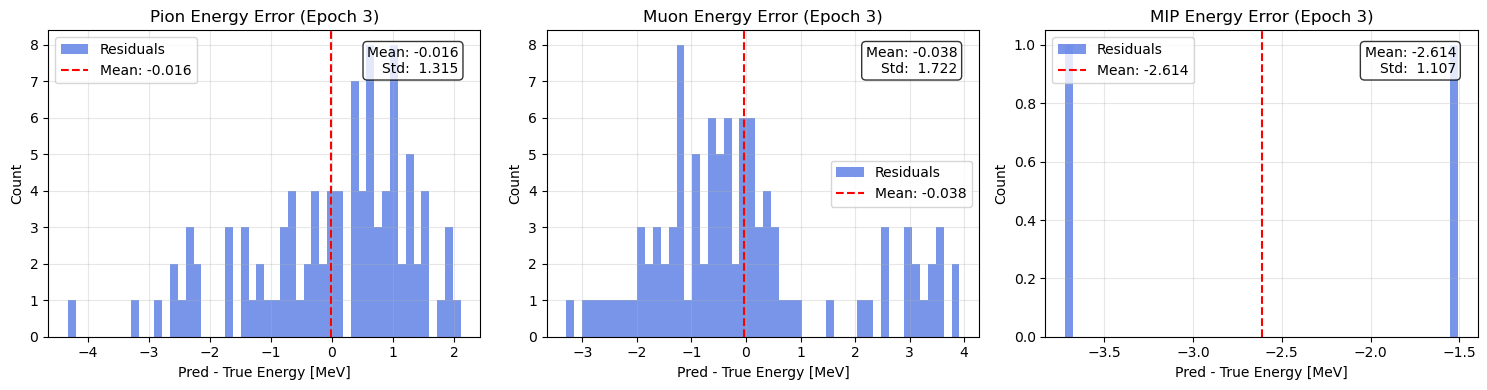

Epoch 04 | Train Loss: 1.7393 (Node: 0.3380, Energy: 1.4013) | Node Acc: 0.8176


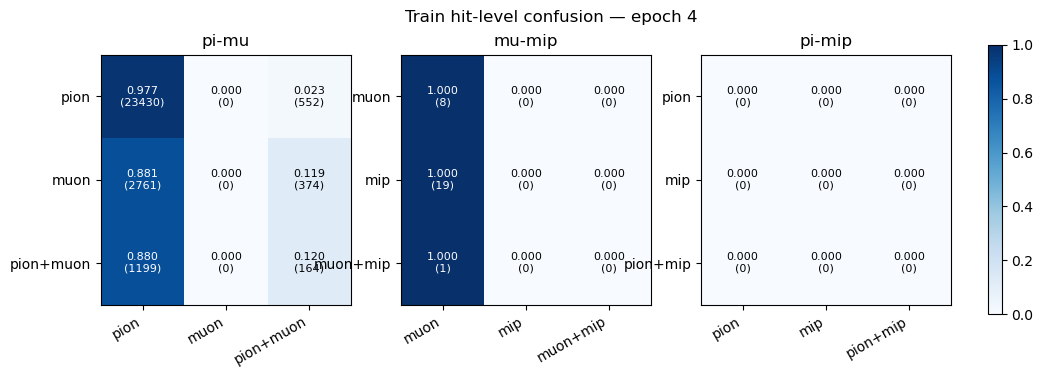

         | Val Loss: 1.7577 | Val Acc: 0.8063


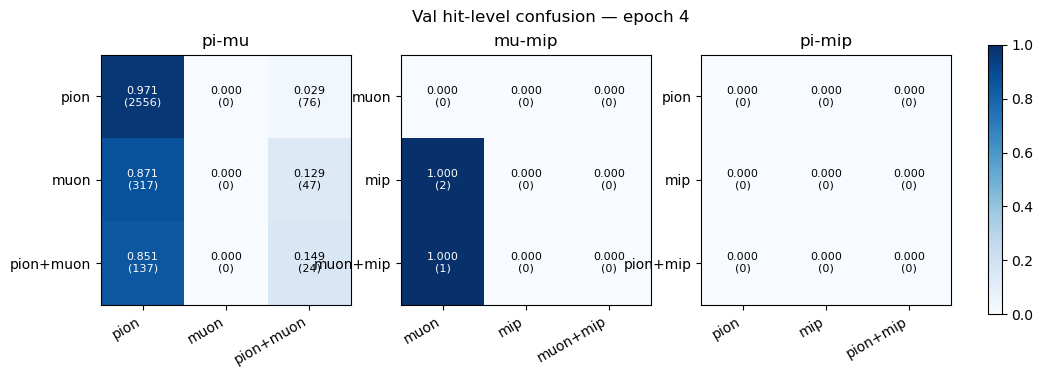

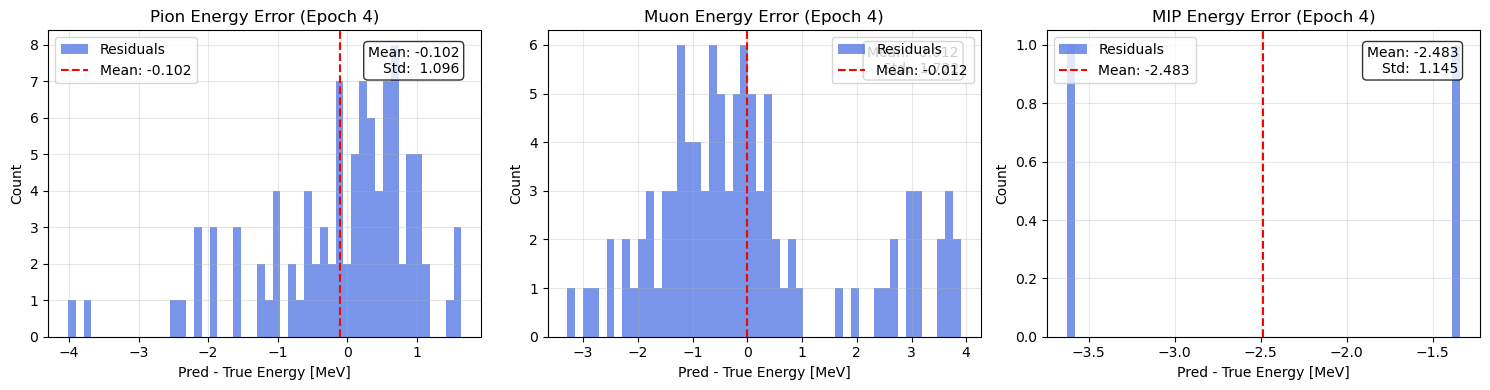

Epoch 05 | Train Loss: 1.6711 (Node: 0.3156, Energy: 1.3555) | Node Acc: 0.8166


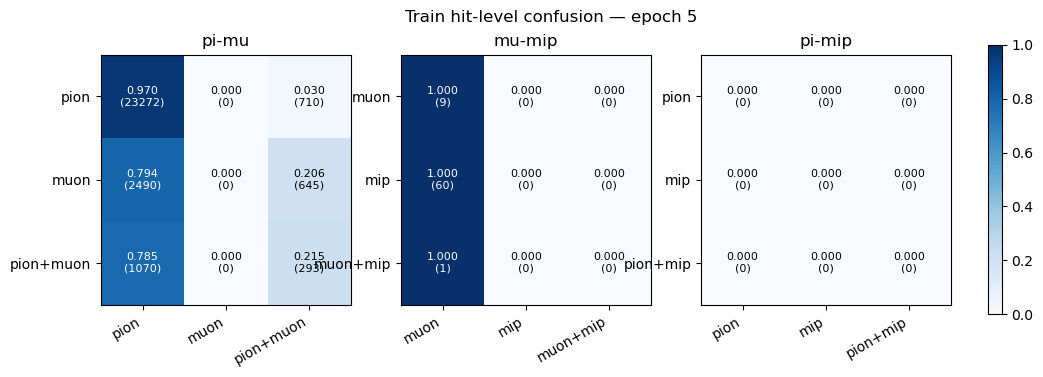

         | Val Loss: 1.7508 | Val Acc: 0.8097


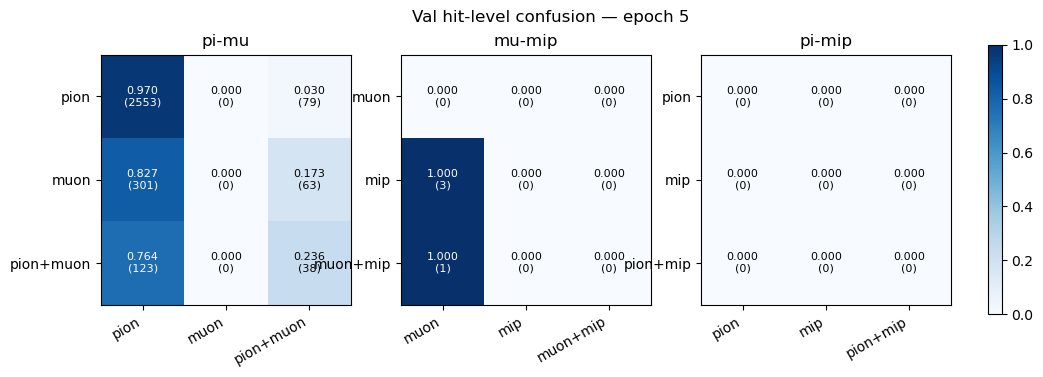

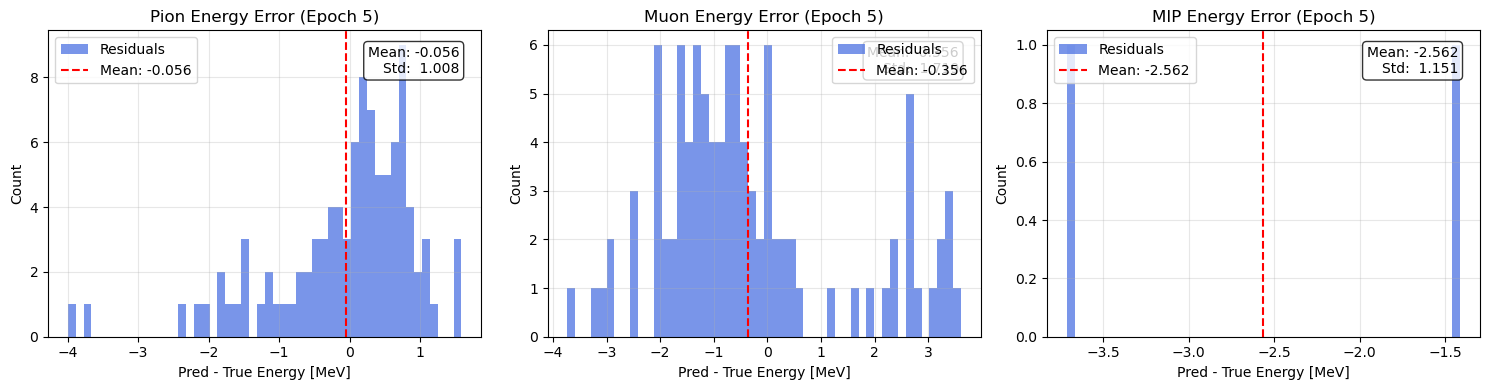

Epoch 06 | Train Loss: 1.6361 (Node: 0.2978, Energy: 1.3383) | Node Acc: 0.8175


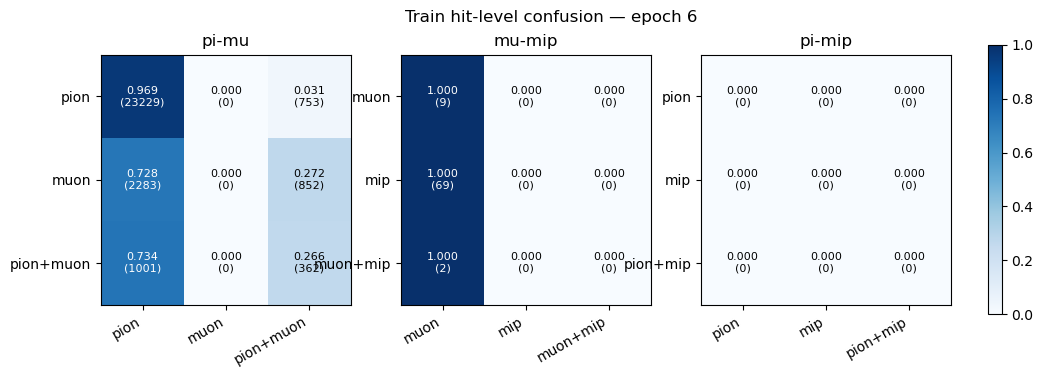

         | Val Loss: 1.6845 | Val Acc: 0.8109


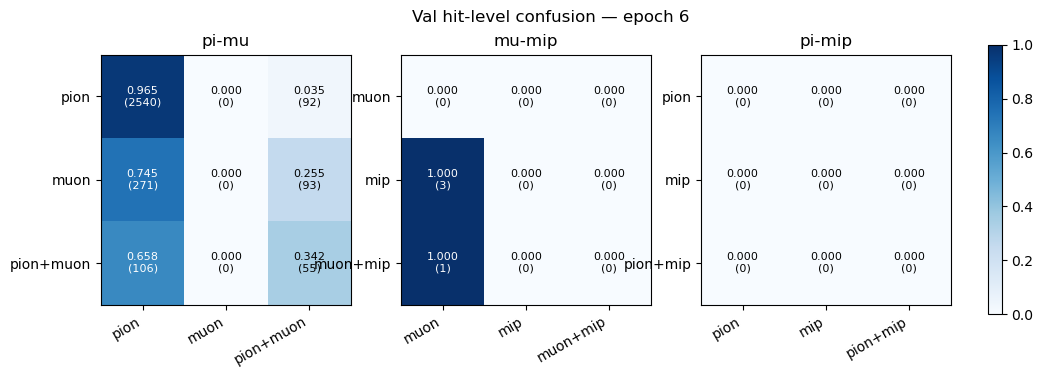

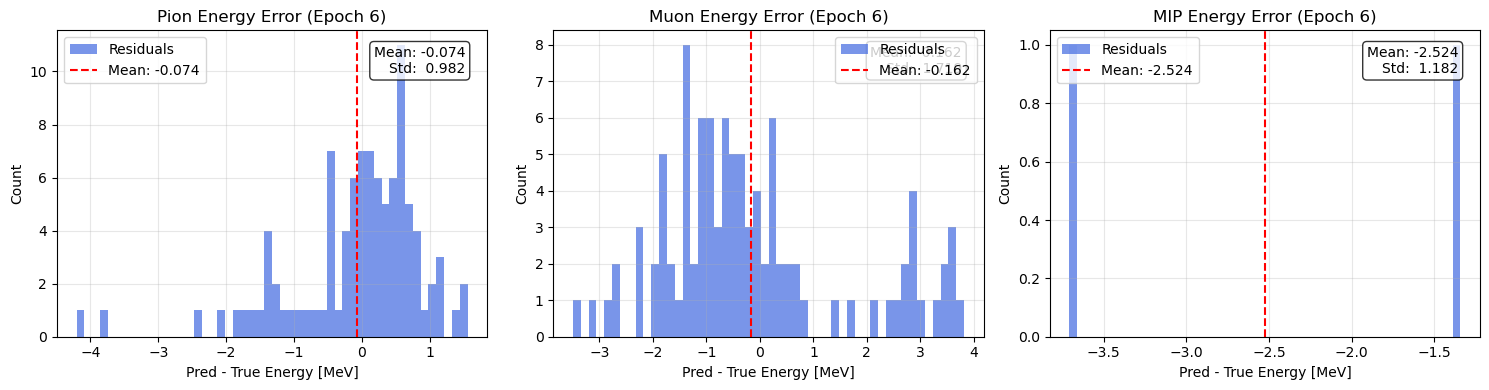

Epoch 07 | Train Loss: 1.5995 (Node: 0.2822, Energy: 1.3173) | Node Acc: 0.8183


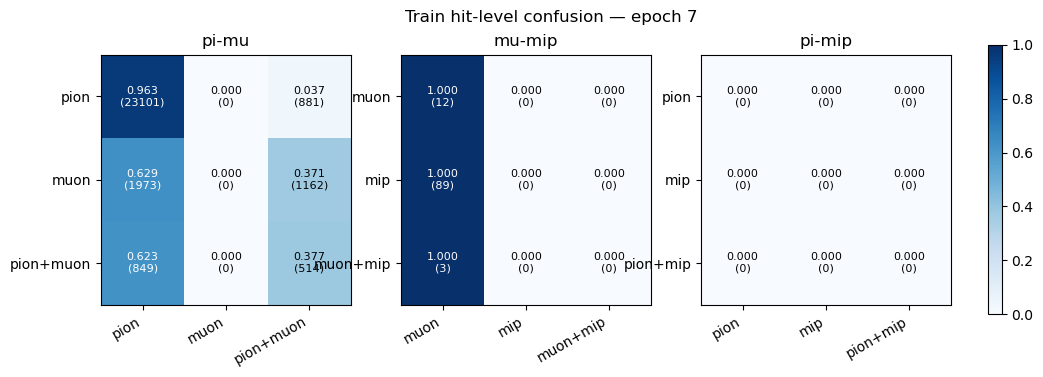

         | Val Loss: 1.6845 | Val Acc: 0.8153


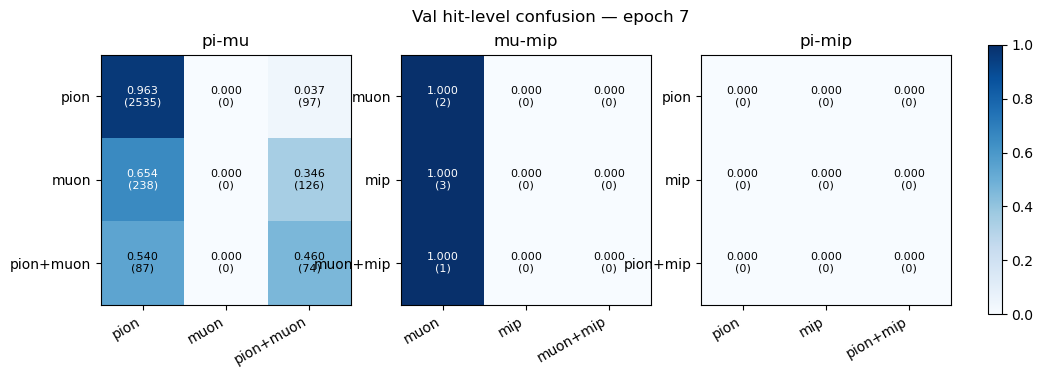

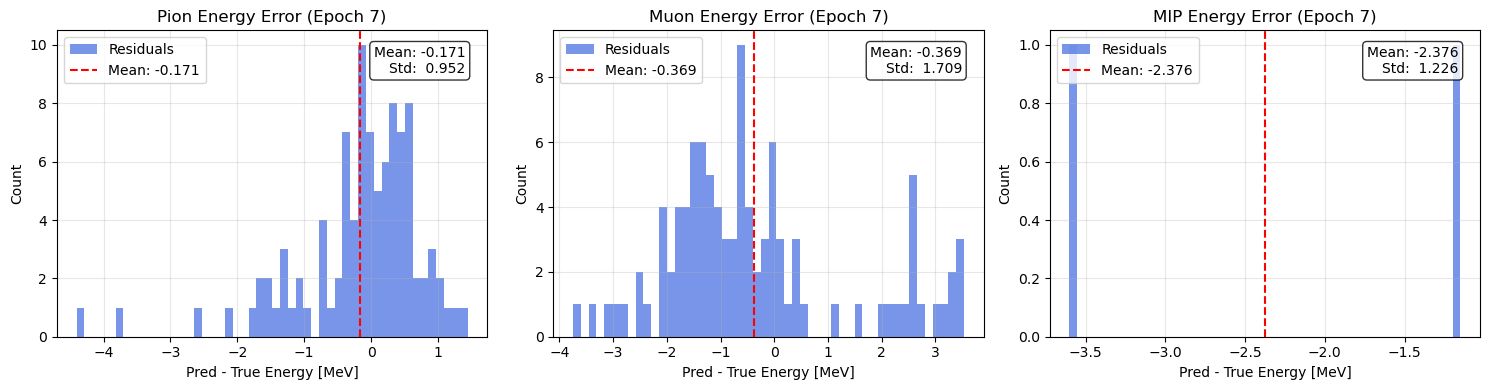

Epoch 08 | Train Loss: 1.5702 (Node: 0.2682, Energy: 1.3019) | Node Acc: 0.8223


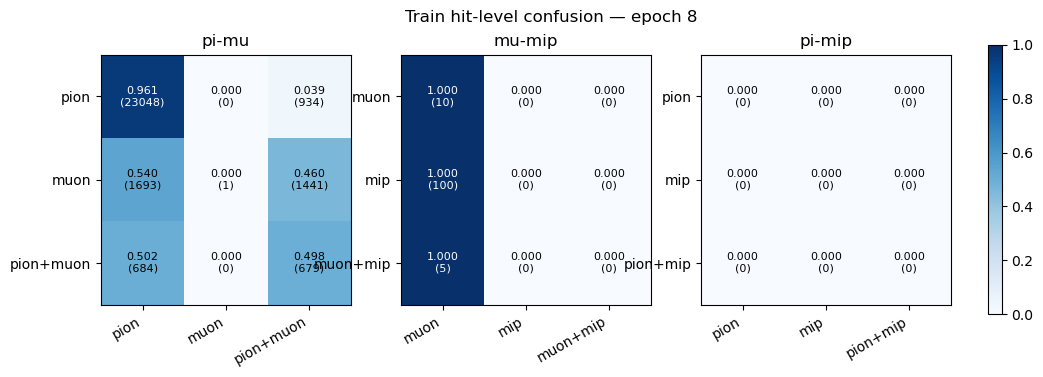

         | Val Loss: 1.6621 | Val Acc: 0.8197


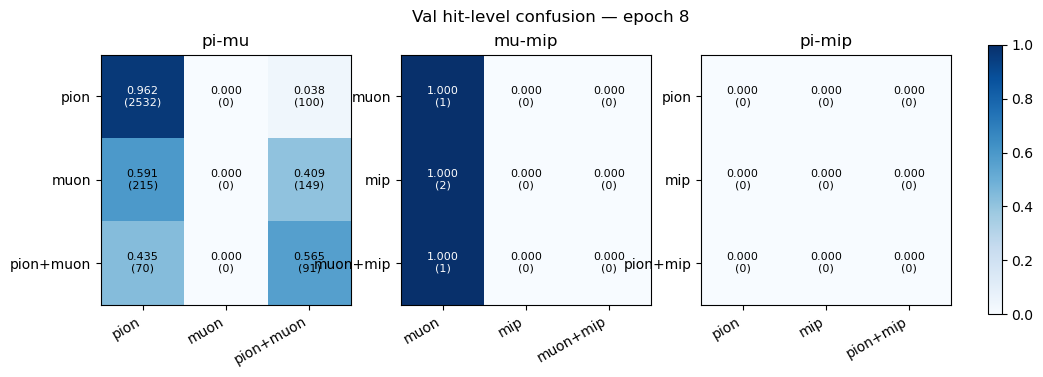

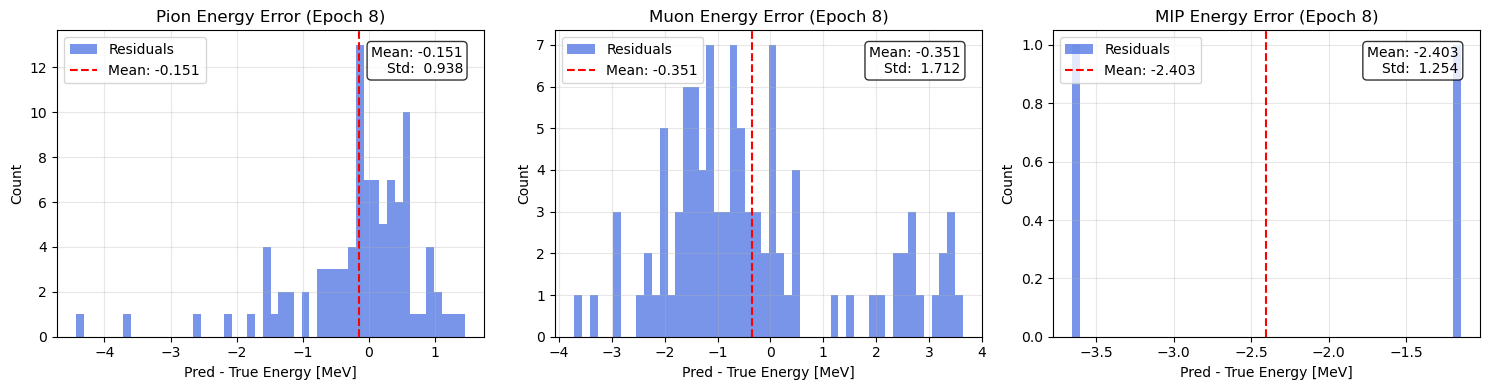

Epoch 09 | Train Loss: 1.5591 (Node: 0.2561, Energy: 1.3029) | Node Acc: 0.8244


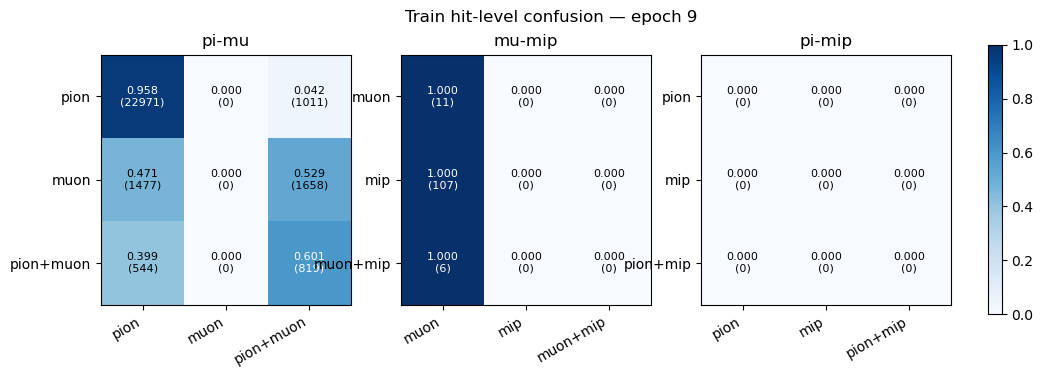

         | Val Loss: 1.6094 | Val Acc: 0.8200


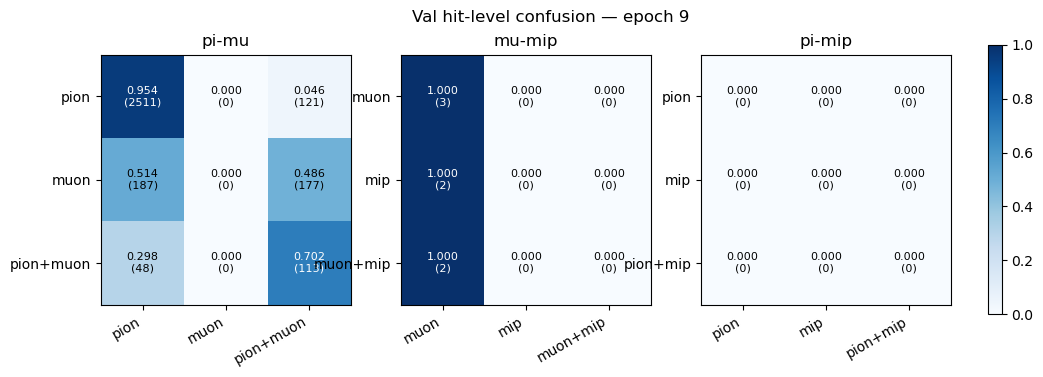

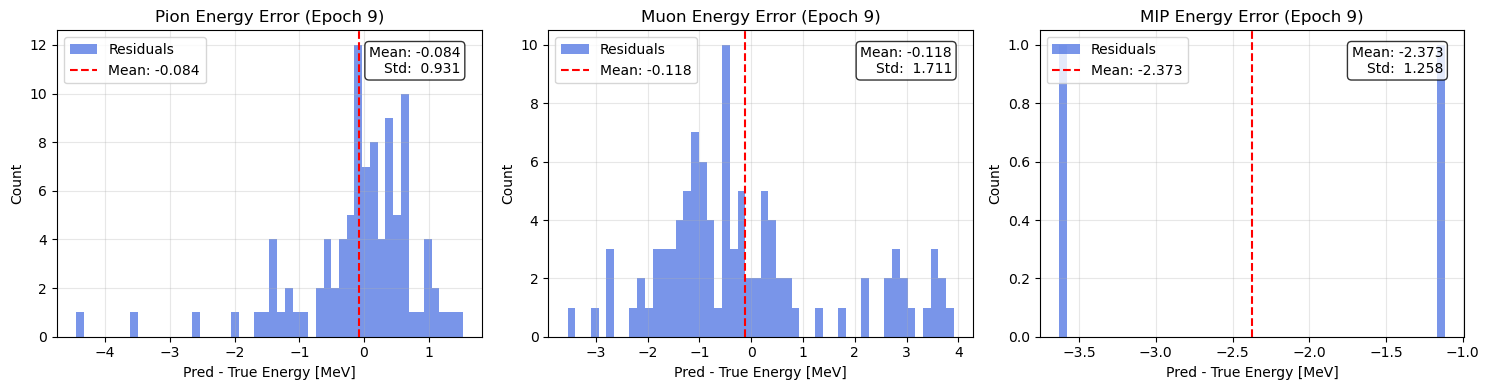

Epoch 10 | Train Loss: 1.5236 (Node: 0.2456, Energy: 1.2781) | Node Acc: 0.8250


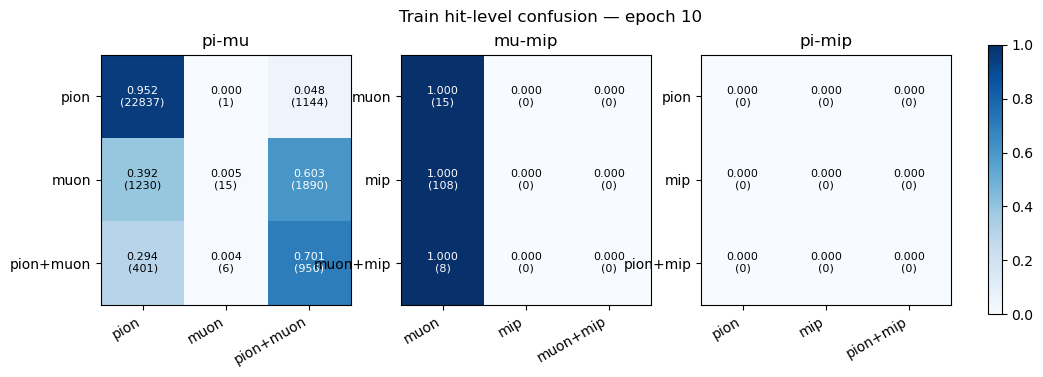

         | Val Loss: 1.6195 | Val Acc: 0.8187


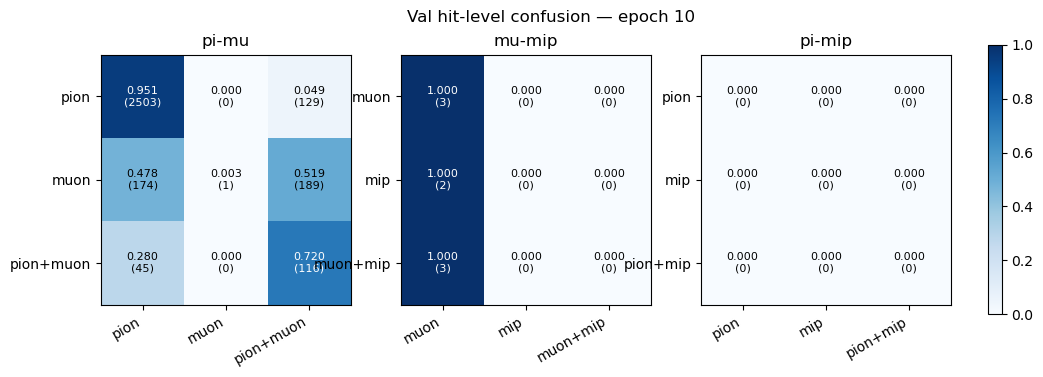

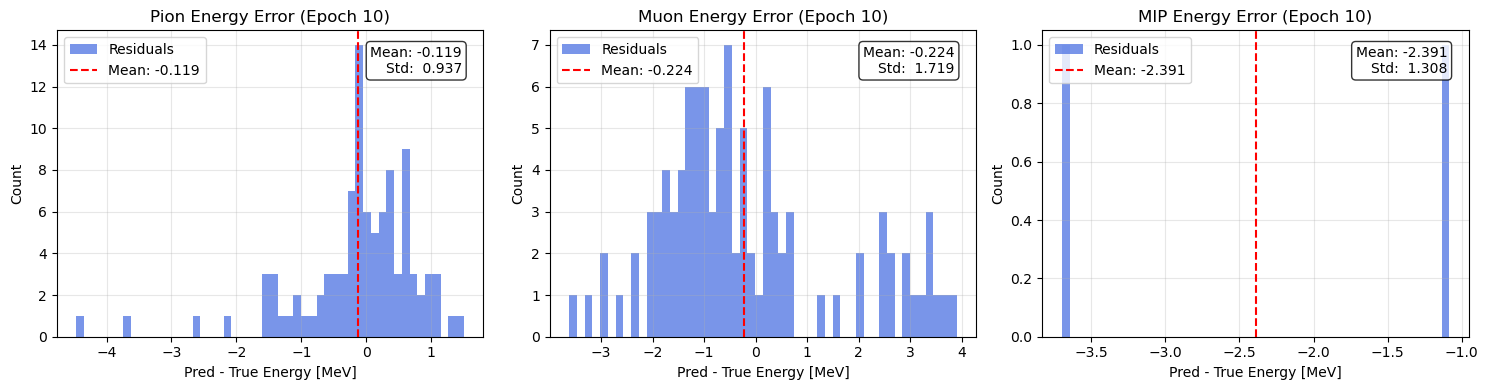

KeyboardInterrupt: 

In [7]:
train_splitter(
    groups,
    model=model,
    batch_size = 32,
    epochs = 20,
    lr = 1e-4,
    energy_lambda = 1.0,
    grad_clip = None,
    threshold = 0.5)